# 03 – Strategy Overview
Visual tour of every strategy's signals on a single asset.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from core.data_fetcher import get_data
from strategies import STRATEGY_REGISTRY

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)

In [2]:
TICKER = 'AAPL'
df = get_data(TICKER, source='yfinance', period='1y')
print(df.tail(3))

                  open        high         low       close    volume
date                                                                
2026-06-01  309.630005  310.940002  305.019989  306.309998  48849900
2026-06-02  307.459991  315.450012  306.690002  315.200012  44416900
2026-06-03  314.174988  316.940002  314.000000  314.359985   9842378


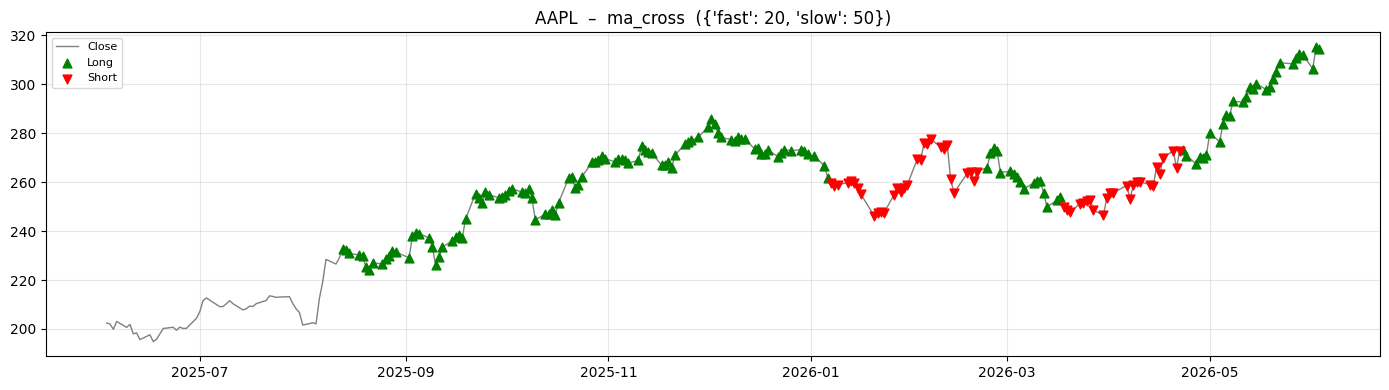

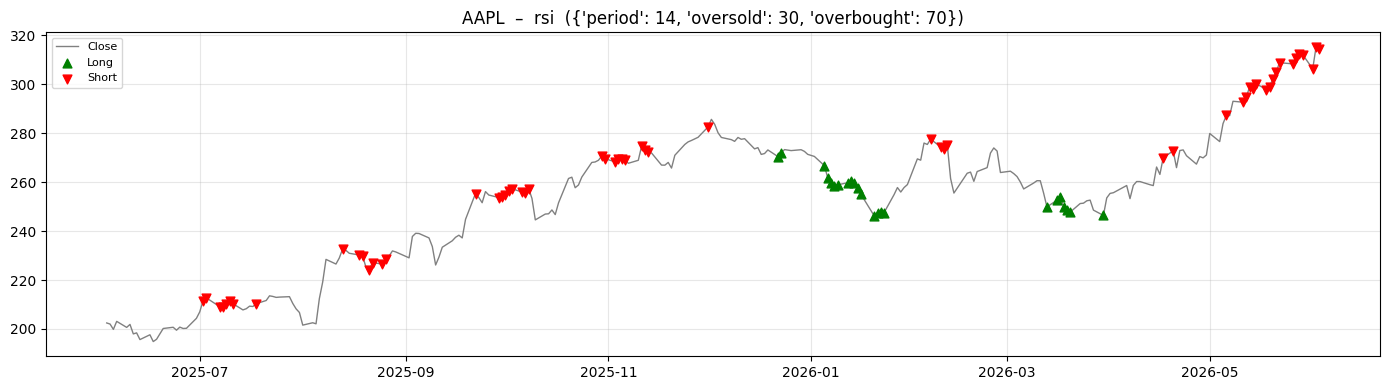

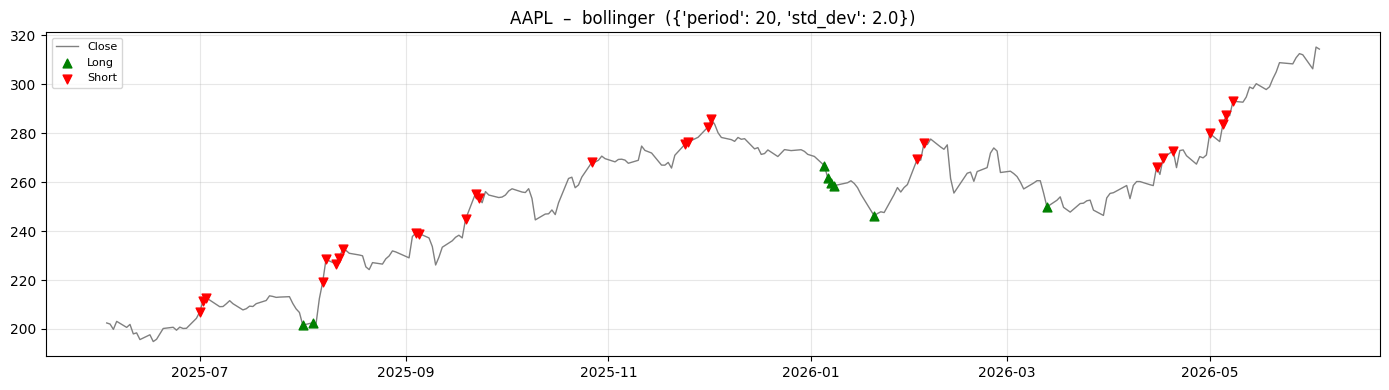

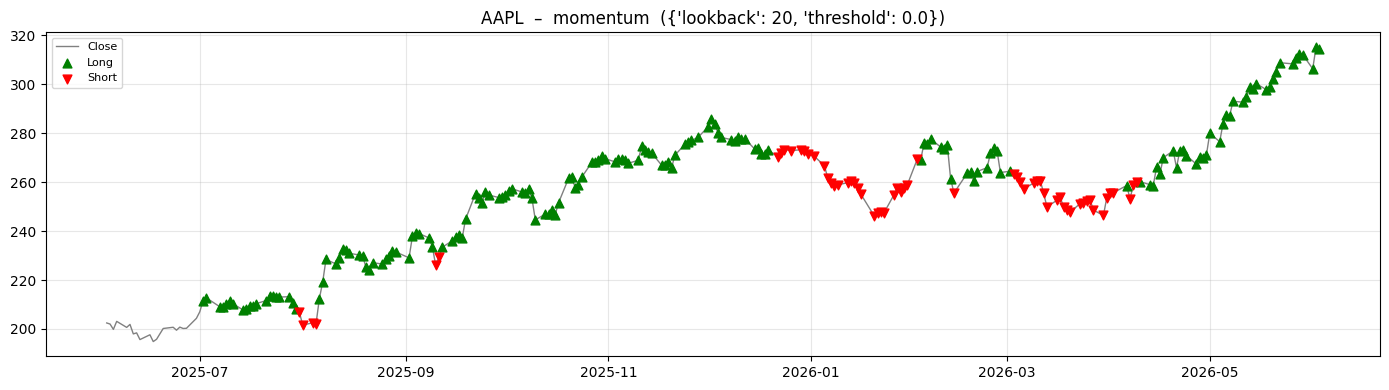

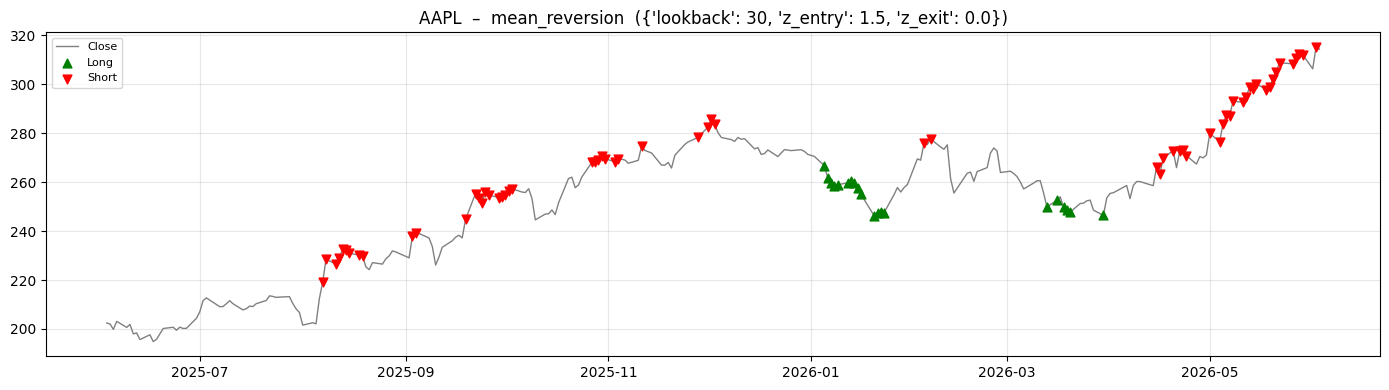

In [3]:
# Plot price + buy/sell markers for each strategy
for name, cls in STRATEGY_REGISTRY.items():
    strat = cls()
    signals = strat.generate_signals(df)

    fig, ax = plt.subplots()
    ax.plot(df.index, df['close'], color='grey', lw=1, label='Close')

    buys  = df['close'][signals ==  1]
    sells = df['close'][signals == -1]
    ax.scatter(buys.index,  buys,  marker='^', color='green', s=40, zorder=5, label='Long')
    ax.scatter(sells.index, sells, marker='v', color='red',   s=40, zorder=5, label='Short')

    ax.set_title(f'{TICKER}  –  {name}  ({strat.params})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()